Using Device: cpu

TASK 2018
Epoch 0 Loss: 1.128802
Epoch 50 Loss: 0.021827
Epoch 100 Loss: 0.009773
Epoch 150 Loss: 0.006523
Epoch 200 Loss: 0.005604
Epoch 250 Loss: 0.005267
RMSE : 0.05709765415185916
MAE  : 0.03345802568527761
R²   : 0.9413752358308664
Training Time: 0.86 seconds

TASK 2019
Epoch 0 Loss: 0.009142
Epoch 50 Loss: 0.008058
Epoch 100 Loss: 0.007754
Epoch 150 Loss: 0.00756
Epoch 200 Loss: 0.007408
Epoch 250 Loss: 0.00728
RMSE : 0.07343112243590846
MAE  : 0.05200584775935698
R²   : 0.921501604887439
Training Time: 0.851 seconds

TASK 2020
Epoch 0 Loss: 0.004177
Epoch 50 Loss: 0.003483
Epoch 100 Loss: 0.00334
Epoch 150 Loss: 0.003249
Epoch 200 Loss: 0.003177
Epoch 250 Loss: 0.003123
RMSE : 0.05094864045761134
MAE  : 0.03300465270892436
R²   : 0.9582257719839795
Training Time: 0.837 seconds

TASK 2021
Epoch 0 Loss: 0.008142
Epoch 50 Loss: 0.007316
Epoch 100 Loss: 0.007012
Epoch 150 Loss: 0.006811
Epoch 200 Loss: 0.006635
Epoch 250 Loss: 0.006484
RMSE : 0.05441308253154211
M

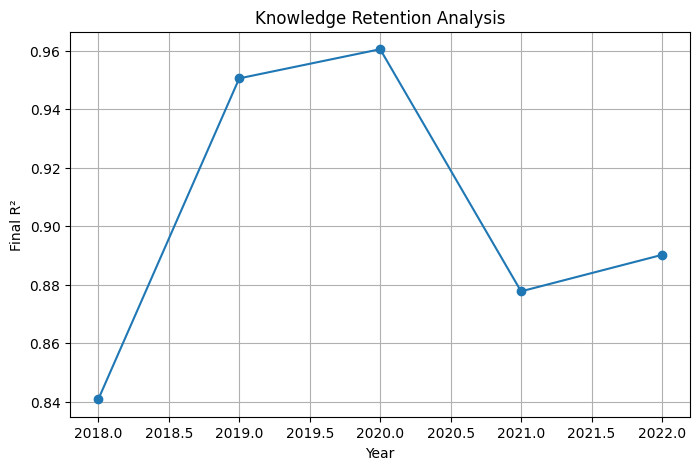

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# =====================================================
# LOAD DATA
# =====================================================

try:
    df2018 = pd.read_excel("../data/2018.xlsx")
    df2019 = pd.read_excel("../data/2019.xlsx")
    df2020 = pd.read_excel("../data/2020.xlsx")
    df2021 = pd.read_excel("../data/2021.xlsx")
    df2022 = pd.read_excel("../data/2022.xlsx")
except FileNotFoundError as exc:
    raise FileNotFoundError("Place the Excel files in the current working directory.") from exc


# =====================================================
# PREPROCESS
# =====================================================


def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    df["hour"] = df["time"].dt.hour
    df["dayofyear"] = df["time"].dt.dayofyear

    df["sst_lag1"] = df["sst"].shift(1)
    df["sst_lag8"] = df["sst"].shift(8)
    df["sst_lag24"] = df["sst"].shift(24)

    df = df.dropna().reset_index(drop=True)
    return df


# =====================================================
# BUILD TASKS
# =====================================================


df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

tasks = [df2018, df2019, df2020, df2021, df2022]

features = ["month", "day", "hour", "dayofyear", "sst_lag1", "sst_lag8", "sst_lag24"]
target = "sst"

# =====================================================
# DEVICE
# =====================================================


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# =====================================================
# MODEL
# =====================================================


class SSTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


class EWC:
    def __init__(self, model):
        self.model = model
        self.params = {n: p.detach().clone() for n, p in model.named_parameters()}
        self.fisher = {}

    def compute_fisher(self, X, y):
        self.model.zero_grad()
        pred = self.model(X)
        loss = nn.MSELoss()(pred, y)
        loss.backward()

        self.fisher = {
            n: p.grad.detach().clone() ** 2
            for n, p in self.model.named_parameters()
        }

    def penalty(self):
        loss = 0.0
        for n, p in self.model.named_parameters():
            loss += (self.fisher[n] * (p - self.params[n]) ** 2).sum()
        return loss


# =====================================================
# TRAINING SETTINGS
# =====================================================


epochs = 300
lr = 0.001
lambda_ewc = 10

model = SSTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

ewc = None

rmses = []
maes = []
r2s = []
retention_rmse = []
retention_r2 = []

test_sets = []
total_time = 0.0

# =====================================================
# TASK LOOP
# =====================================================

for i, task in enumerate(tasks):
    year = 2018 + i

    print("\n===================================")
    print(f"TASK {year}")
    print("===================================")

    X = task[features].values
    y = task[target].values

    split = int(len(X) * 0.8)
    X_train = X[:split]
    X_test = X[split:]
    y_train = y[:split]
    y_test = y[split:]

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

    test_sets.append({
        "year": year,
        "X_test": X_test.cpu().numpy(),
        "y_test": y_test,
        "y_scaler": y_scaler,
    })

    start = time.time()
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X_train)
        loss = criterion(preds, y_train_scaled)

        

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch} Loss:", round(loss.item(), 6))

    train_time = time.time() - start
    total_time += train_time

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R²   :", r2)
    print("Training Time:", round(train_time, 3), "seconds")

    ewc = EWC(model)
    ewc.compute_fisher(X_train, y_train_scaled)
    
# =====================================================
# FINAL RESULTS
# =====================================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print("Average RMSE:", round(np.mean(rmses), 4))
print("Average MAE:", round(np.mean(maes), 4))
print("Average R²:", round(np.mean(r2s), 4))
print("Total Time:", round(total_time, 3), "seconds")

# =====================================================
# RETENTION ANALYSIS
# =====================================================

print("\n===================================")
print("RETENTION ANALYSIS")
print("===================================")

mlp_retention = retention_r2.copy()

print("\nMLP Retention")
print(mlp_retention)
# =====================================
# RETENTION STORAGE
# =====================================

for item in test_sets:
    year = item["year"]
    X_test = torch.tensor(item["X_test"], dtype=torch.float32).to(device)
    y_test = item["y_test"]
    y_scaler = item["y_scaler"]

    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    retention_rmse.append(rmse)
    retention_r2.append(r2)

    print("Year", year)
    print("Final RMSE:", round(rmse, 4))
    print("Final R²:", round(r2, 4))
    print("-------------------")

mlp_retention = retention_r2.copy()
print("\nMLP Retention")
print(mlp_retention)

plt.figure(figsize=(8, 5))
plt.plot([item["year"] for item in test_sets], retention_r2, marker="o")
plt.xlabel("Year")
plt.ylabel("Final R²")
plt.title("Knowledge Retention Analysis")
plt.grid(True)
plt.show()


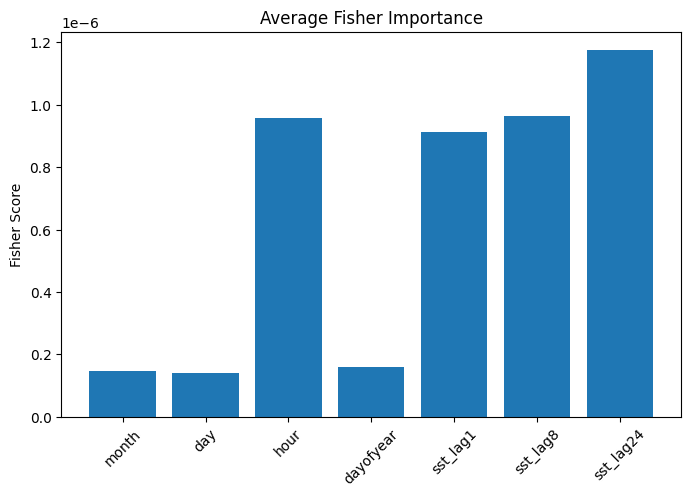

In [2]:
fisher_layer = ewc.fisher['net.0.weight']

feature_fisher = (
    fisher_layer
    .cpu()
    .numpy()
    .sum(axis=0)
)

plt.figure(figsize=(8,5))

plt.bar(
    features,
    feature_fisher
)

plt.title(
    "Average Fisher Importance"
)

plt.ylabel(
    "Fisher Score"
)

plt.xticks(rotation=45)

plt.show()

Using Device: cpu

TASK 2018
Epoch 0 Loss: 0.987043
Epoch 50 Loss: 0.025331
Epoch 100 Loss: 0.010994
Epoch 150 Loss: 0.006718
Epoch 200 Loss: 0.005556
Epoch 250 Loss: 0.005205
RMSE : 0.05583708165130728
MAE  : 0.035366660410913874
R²   : 0.9439352357185434
Training Time: 1.31 seconds

TASK 2019
Epoch 0 Loss: 0.008874
Epoch 50 Loss: 0.007976
Epoch 100 Loss: 0.007714
Epoch 150 Loss: 0.007529
Epoch 200 Loss: 0.007379
Epoch 250 Loss: 0.007249
RMSE : 0.06814081368287148
MAE  : 0.04612446395345767
R²   : 0.9324049217887456
Training Time: 1.471 seconds

TASK 2020
Epoch 0 Loss: 0.004364
Epoch 50 Loss: 0.003587
Epoch 100 Loss: 0.003449
Epoch 150 Loss: 0.003363
Epoch 200 Loss: 0.003301
Epoch 250 Loss: 0.003249
RMSE : 0.05028827990050372
MAE  : 0.030824612331164295
R²   : 0.9593016506218971
Training Time: 1.299 seconds

TASK 2021
Epoch 0 Loss: 0.007968
Epoch 50 Loss: 0.007283
Epoch 100 Loss: 0.00705
Epoch 150 Loss: 0.006854
Epoch 200 Loss: 0.006681
Epoch 250 Loss: 0.006519
RMSE : 0.05332421187554

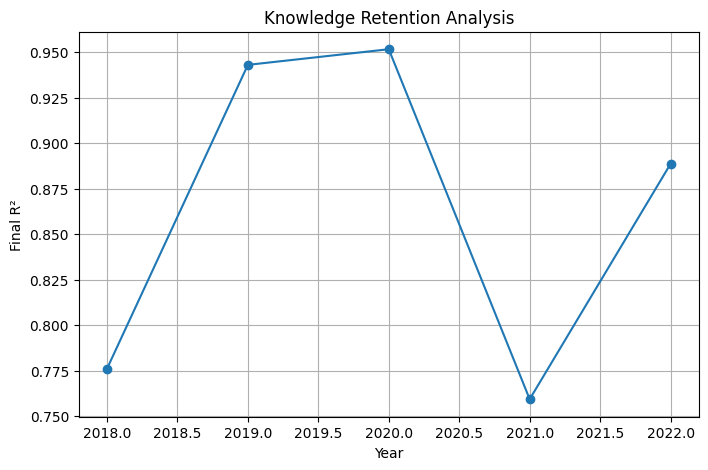

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# =====================================================
# LOAD DATA
# =====================================================

try:
    df2018 = pd.read_excel("2018.xlsx")
    df2019 = pd.read_excel("2019.xlsx")
    df2020 = pd.read_excel("2020.xlsx")
    df2021 = pd.read_excel("2021.xlsx")
    df2022 = pd.read_excel("2022.xlsx")
except FileNotFoundError as exc:
    raise FileNotFoundError("Place the Excel files in the current working directory.") from exc


# =====================================================
# PREPROCESS
# =====================================================


def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    df["hour"] = df["time"].dt.hour
    df["dayofyear"] = df["time"].dt.dayofyear

    df["sst_lag1"] = df["sst"].shift(1)
    df["sst_lag8"] = df["sst"].shift(8)
    df["sst_lag24"] = df["sst"].shift(24)

    df = df.dropna().reset_index(drop=True)
    return df


# =====================================================
# BUILD TASKS
# =====================================================


df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

tasks = [df2018, df2019, df2020, df2021, df2022]

features = ["month", "day", "hour", "dayofyear", "sst_lag1", "sst_lag8", "sst_lag24"]
target = "sst"

# =====================================================
# DEVICE
# =====================================================


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

model = SSTNet().to(device)

model.load_state_dict(
    torch.load("best_sst_model.pth")
)

optimizer = optim.Adam(
    model.parameters(),
    lr=lr
)

model.eval()

# =====================================================
# MODEL
# =====================================================


class SSTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


class EWC:
    def __init__(self, model):
        self.model = model
        self.params = {n: p.detach().clone() for n, p in model.named_parameters()}
        self.fisher = {}

    def compute_fisher(self, X, y):
        self.model.zero_grad()
        pred = self.model(X)
        loss = nn.MSELoss()(pred, y)
        loss.backward()

        self.fisher = {
            n: p.grad.detach().clone() ** 2
            for n, p in self.model.named_parameters()
        }

    def penalty(self):
        loss = 0.0
        for n, p in self.model.named_parameters():
            loss += (self.fisher[n] * (p - self.params[n]) ** 2).sum()
        return loss


# =====================================================
# TRAINING SETTINGS
# =====================================================


epochs = 300
lr = 0.001
lambda_ewc = 5

model = SSTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

ewc = None

rmses = []
maes = []
r2s = []
retention_rmse = []
retention_r2 = []

test_sets = []
total_time = 0.0

# =====================================================
# TASK LOOP
# =====================================================

for i, task in enumerate(tasks):
    year = 2018 + i

    print("\n===================================")
    print(f"TASK {year}")
    print("===================================")

    X = task[features].values
    y = task[target].values

    split = int(len(X) * 0.8)
    X_train = X[:split]
    X_test = X[split:]
    y_train = y[:split]
    y_test = y[split:]

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

    test_sets.append({
        "year": year,
        "X_test": X_test.cpu().numpy(),
        "y_test": y_test,
        "y_scaler": y_scaler,
    })

    start = time.time()
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X_train)
        loss = criterion(preds, y_train_scaled)
    
        if ewc is not None:
            loss += lambda_ewc * ewc.penalty()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch} Loss:", round(loss.item(), 6))

    train_time = time.time() - start
    total_time += train_time

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R²   :", r2)
    print("Training Time:", round(train_time, 3), "seconds")

    ewc = EWC(model)
    ewc.compute_fisher(X_train, y_train_scaled)
    
# =====================================================
# FINAL RESULTS
# =====================================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print("Average RMSE:", round(np.mean(rmses), 4))
print("Average MAE:", round(np.mean(maes), 4))
print("Average R²:", round(np.mean(r2s), 4))
print("Total Time:", round(total_time, 3), "seconds")

# =====================================================
# RETENTION ANALYSIS
# =====================================================

print("\n===================================")
print("RETENTION ANALYSIS")
print("===================================")



print("\nMLP Retention")
print(mlp_retention)
# =====================================
# RETENTION STORAGE
# =====================================

for item in test_sets:
    year = item["year"]
    X_test = torch.tensor(item["X_test"], dtype=torch.float32).to(device)
    y_test = item["y_test"]
    y_scaler = item["y_scaler"]

    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    retention_rmse.append(rmse)
    retention_r2.append(r2)

    print("Year", year)
    print("Final RMSE:", round(rmse, 4))
    print("Final R²:", round(r2, 4))
    print("-------------------")

mlp_retention = retention_r2.copy()
print("\nMLP Retention")
print(mlp_retention)
plt.figure(figsize=(8, 5))
plt.plot([item["year"] for item in test_sets], retention_r2, marker="o")
plt.xlabel("Year")
plt.ylabel("Final R²")
plt.title("Knowledge Retention Analysis")
plt.grid(True)
plt.show()


In [12]:
torch.save(
    model.state_dict(),
    "best_sst_model.pth"
)

print("Model Saved!")

Model Saved!


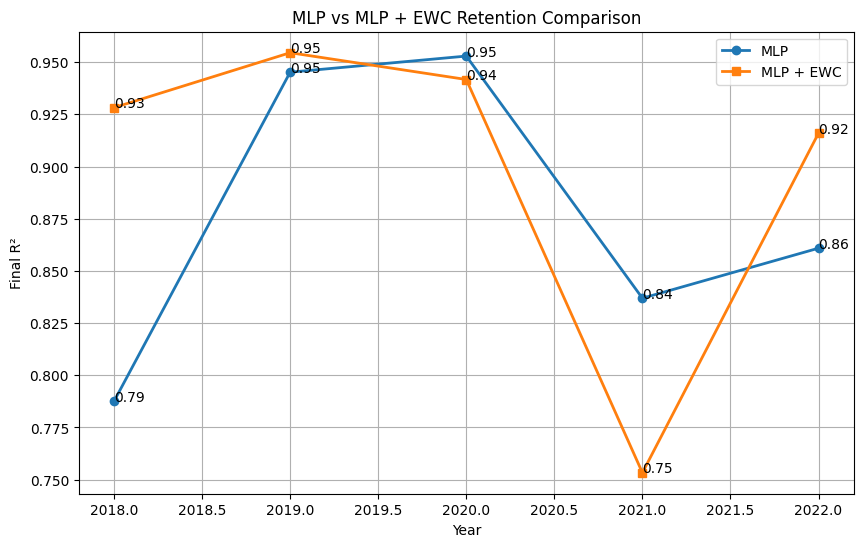

In [4]:
import matplotlib.pyplot as plt

years = [
    2018,
    2019,
    2020,
    2021,
    2022
]

# Replace with your actual values

mlp_retention = [0.787496265121325, 0.945202429571969, 0.9529298916202977, 0.8369046923597527, 0.8608720601070725]

ewc_retention = [0.9282294994932943, 0.954535425426799, 0.9417022645787058, 0.7532788044142444, 0.9159983911054106]

plt.figure(figsize=(10,6))

plt.plot(
    years,
    mlp_retention,
    marker='o',
    linewidth=2,
    label='MLP'
)

plt.plot(
    years,
    ewc_retention,
    marker='s',
    linewidth=2,
    label='MLP + EWC'
)

for x,y in zip(years, mlp_retention):

    plt.text(
        x,
        y,
        f"{y:.2f}"
    )

for x,y in zip(years, ewc_retention):

    plt.text(
        x,
        y,
        f"{y:.2f}"
    )

plt.xlabel("Year")
plt.ylabel("Final R²")
plt.title("MLP vs MLP + EWC Retention Comparison")

plt.legend()

plt.grid(True)

plt.show()

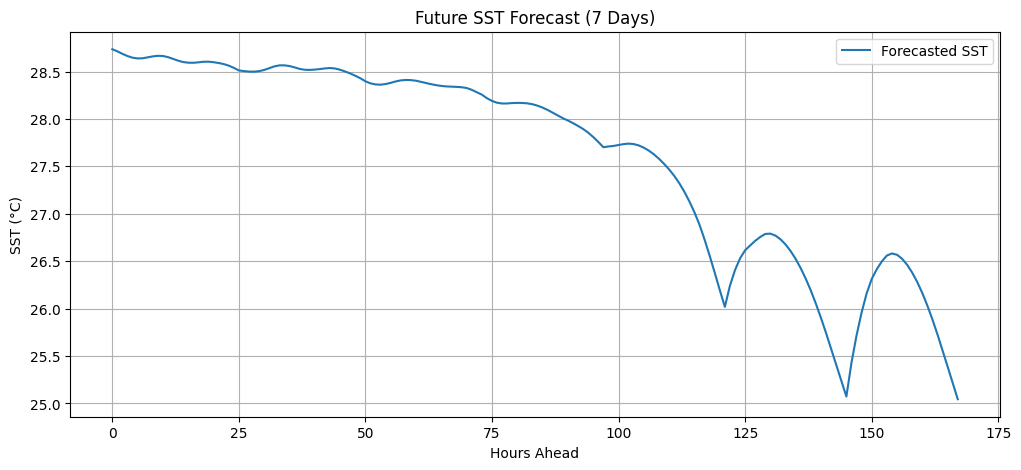

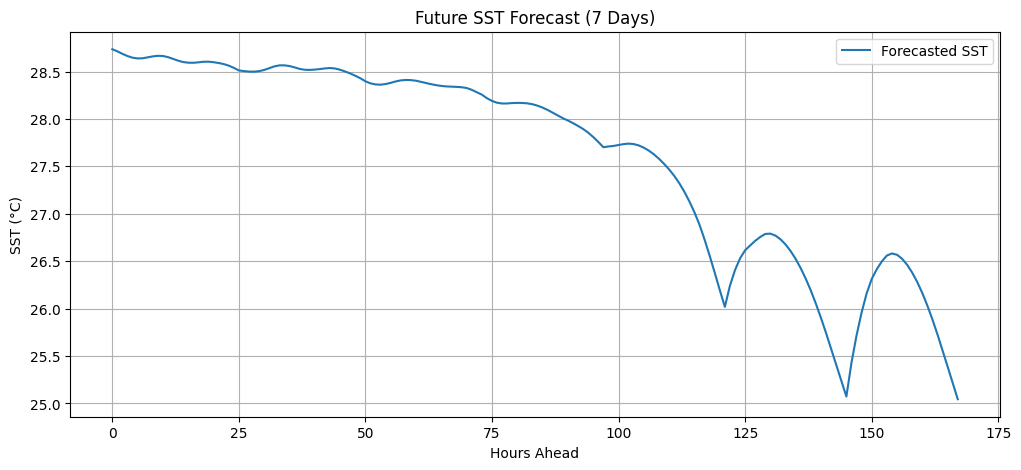

In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# =====================================
# LAST KNOWN DATA
# =====================================

last_df = df2022.copy()

future_steps = 24*7

future_preds = []

# use last 24 SST values
sst_history = list(
    last_df["sst"].values[-24:]
)

# last timestamp
current_time = pd.to_datetime(
    last_df["time"].iloc[-1]
)

# =====================================
# RECURSIVE FORECASTING
# =====================================

for step in range(future_steps):

    current_time = current_time + pd.Timedelta(hours=1)

    month = current_time.month
    day = current_time.day
    hour = current_time.hour
    dayofyear = current_time.dayofyear

    lag1 = sst_history[-1]
    lag8 = sst_history[-8]
    lag24 = sst_history[-24]

    X_future = np.array([[
        month,
        day,
        hour,
        dayofyear,
        lag1,
        lag8,
        lag24
    ]])

    # IMPORTANT:
    # Use SAME scaler from final task
    X_future = x_scaler.transform(
        X_future
    )

    X_future = torch.tensor(
        X_future,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        pred_scaled = model(
            X_future
        ).cpu().numpy()

    pred = y_scaler.inverse_transform(
        pred_scaled
    )[0][0]

    future_preds.append(pred)

    sst_history.append(pred)

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(12,5))

plt.plot(
    future_preds,
    label="Forecasted SST"
)

plt.xlabel("Hours Ahead")

plt.ylabel("SST (°C)")

plt.title(
    "Future SST Forecast (7 Days)"
)

plt.legend()

plt.grid(True)

plt.show()

In [36]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# =====================================================
# LOAD DATA
# =====================================================

try:
    df2018 = pd.read_excel("2018.xlsx")
    df2019 = pd.read_excel("2019.xlsx")
    df2020 = pd.read_excel("2020.xlsx")
    df2021 = pd.read_excel("2021.xlsx")
    df2022 = pd.read_excel("2022.xlsx")
except FileNotFoundError as exc:
    raise FileNotFoundError("Place the Excel files in the current working directory.") from exc


# =====================================================
# PREPROCESS
# =====================================================


def preprocess(df):
    df = df[["time", "sst"]].copy()
    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["day"] = df["time"].dt.day
    df["hour"] = df["time"].dt.hour
    df["dayofyear"] = df["time"].dt.dayofyear

    df["sst_lag1"] = df["sst"].shift(1)
    df["sst_lag8"] = df["sst"].shift(8)
    df["sst_lag24"] = df["sst"].shift(24)

    df = df.dropna().reset_index(drop=True)
    return df


# =====================================================
# BUILD TASKS
# =====================================================


df2018 = preprocess(df2018)
df2019 = preprocess(df2019)
df2020 = preprocess(df2020)
df2021 = preprocess(df2021)
df2022 = preprocess(df2022)

tasks = [df2018, df2019, df2020, df2021, df2022]

features = ["sst_lag1","sst_lag8","sst_lag24"]

target = "sst"

# =====================================================
# DEVICE
# =====================================================


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)




model.eval()

# =====================================================
# MODEL
# =====================================================


class SSTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


class EWC:
    def __init__(self, model):
        self.model = model
        self.params = {n: p.detach().clone() for n, p in model.named_parameters()}
        self.fisher = {}

    def compute_fisher(self, X, y):
        self.model.zero_grad()
        pred = self.model(X)
        loss = nn.MSELoss()(pred, y)
        loss.backward()

        self.fisher = {
            n: p.grad.detach().clone() ** 2
            for n, p in self.model.named_parameters()
        }

    def penalty(self):
        loss = 0.0
        for n, p in self.model.named_parameters():
            loss += (self.fisher[n] * (p - self.params[n]) ** 2).sum()
        return loss


# =====================================================
# TRAINING SETTINGS
# =====================================================


epochs = 300
lr = 0.001
lambda_ewc = 5

model = SSTNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

ewc = None

rmses = []
maes = []
r2s = []
retention_rmse = []
retention_r2 = []

test_sets = []
total_time = 0.0

# =====================================================
# TASK LOOP
# =====================================================

for i, task in enumerate(tasks):
    year = 2018 + i

    print("\n===================================")
    print(f"TASK {year}")
    print("===================================")

    X = task[features].values
    y = task[target].values

    split = int(len(X) * 0.8)
    X_train = X[:split]
    X_test = X[split:]
    y_train = y[:split]
    y_test = y[split:]

    x_scaler = StandardScaler()
    X_train = x_scaler.fit_transform(X_train)
    X_test = x_scaler.transform(X_test)

    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
    y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_scaled = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    y_test_scaled = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

    test_sets.append({
        "year": year,
        "X_test": X_test.cpu().numpy(),
        "y_test": y_test,
        "y_scaler": y_scaler,
    })

    start = time.time()
    model.train()

    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(X_train)
        loss = criterion(preds, y_train_scaled)
    
        if ewc is not None:
            loss += lambda_ewc * ewc.penalty()
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"Epoch {epoch} Loss:", round(loss.item(), 6))

    train_time = time.time() - start
    total_time += train_time

    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test).cpu().numpy()

    preds = y_scaler.inverse_transform(preds_scaled)
    y_true = y_test.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    rmses.append(rmse)
    maes.append(mae)
    r2s.append(r2)

    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R²   :", r2)
    print("Training Time:", round(train_time, 3), "seconds")

    ewc = EWC(model)
    ewc.compute_fisher(X_train, y_train_scaled)
    
# =====================================================
# FINAL RESULTS
# =====================================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print("Average RMSE:", round(np.mean(rmses), 4))
print("Average MAE:", round(np.mean(maes), 4))
print("Average R²:", round(np.mean(r2s), 4))
print("Total Time:", round(total_time, 3), "seconds")




Using Device: cpu

TASK 2018
Epoch 0 Loss: 0.94637
Epoch 50 Loss: 0.024639
Epoch 100 Loss: 0.010479
Epoch 150 Loss: 0.006717
Epoch 200 Loss: 0.005797
Epoch 250 Loss: 0.005492
RMSE : 0.04827872358240659
MAE  : 0.01929245091090098
R²   : 0.9580862869059097
Training Time: 0.829 seconds

TASK 2019
Epoch 0 Loss: 0.008425
Epoch 50 Loss: 0.008211
Epoch 100 Loss: 0.008087
Epoch 150 Loss: 0.007984
Epoch 200 Loss: 0.007895
Epoch 250 Loss: 0.007823
RMSE : 0.054686914272954266
MAE  : 0.02127717856255608
R²   : 0.9564621195927177
Training Time: 1.17 seconds

TASK 2020
Epoch 0 Loss: 0.004219
Epoch 50 Loss: 0.003754
Epoch 100 Loss: 0.003734
Epoch 150 Loss: 0.003726
Epoch 200 Loss: 0.003718
Epoch 250 Loss: 0.003712
RMSE : 0.03871109485739557
MAE  : 0.015434389222984336
R²   : 0.9758835075766763
Training Time: 1.057 seconds

TASK 2021
Epoch 0 Loss: 0.008871
Epoch 50 Loss: 0.008023
Epoch 100 Loss: 0.007951
Epoch 150 Loss: 0.007904
Epoch 200 Loss: 0.007852
Epoch 250 Loss: 0.007801
RMSE : 0.04954608141377

                 time  predicted_sst
0 2022-12-31 22:00:00      28.753494
1 2022-12-31 23:00:00      28.755442
2 2023-01-01 00:00:00      28.757423
3 2023-01-01 01:00:00      28.759441
4 2023-01-01 02:00:00      28.761494


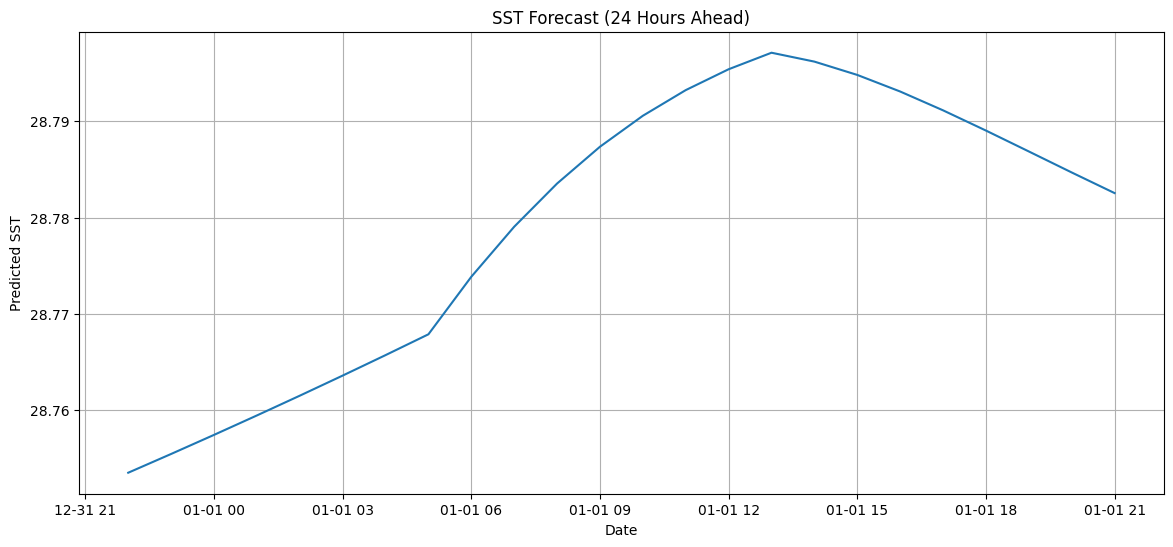

In [38]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# =====================================
# START FROM LAST AVAILABLE DATA
# =====================================

last_df = df2022.copy()

future_steps = 24  # 24 hours

future_preds = []
future_times = []

# last 24 SST values needed
sst_history = list(
    last_df["sst"].values[-24:]
)

current_time = pd.to_datetime(
    last_df["time"].iloc[-1]
)

# =====================================
# FORECAST LOOP
# =====================================

model.eval()

for step in range(future_steps):

    current_time += pd.Timedelta(hours=1)

    future_times.append(current_time)

    lag1 = sst_history[-1]
    lag8 = sst_history[-8]
    lag24 = sst_history[-24]

    X_future = np.array([[
        lag1,
        lag8,
        lag24
    ]])

    # same scaler used in final training task
    X_future = x_scaler.transform(
        X_future
    )

    X_future = torch.tensor(
        X_future,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        pred_scaled = model(
            X_future
        )

    pred_scaled = pred_scaled.cpu().numpy()

    pred = y_scaler.inverse_transform(
        pred_scaled
    )[0][0]

    future_preds.append(pred)

    # recursive update
    sst_history.append(pred)

# =====================================
# FORECAST DATAFRAME
# =====================================

forecast_df = pd.DataFrame({

    "time": future_times,

    "predicted_sst": future_preds

})

print(forecast_df.head())

# =====================================
# PLOT FORECAST
# =====================================

plt.figure(figsize=(14,6))

plt.plot(
    future_times,
    future_preds
)

plt.xlabel("Date")

plt.ylabel("Predicted SST")

plt.title(
    f"SST Forecast ({future_steps} Hours Ahead)"
)

plt.grid(True)

plt.show()